<a href="https://colab.research.google.com/github/Zuckmo/Production-System/blob/main/Capstone_Production_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research questions utama yang ingin dijawab antara lain:
1. Bagaimana machine learning dapat digunakan untuk memprediksi status produksi sehingga tim produksi dapat mengambil tindakan preventif?

    - Supervised L - Classification
    - output = efficient and inefficient

2. Bagaimana machine learning dapat memprediksi mesin yang berpotensi
memerlukan maintenance sehingga dapat mengurangi downtime?
    - Classification
    - mengurangi downtime

3. Bagaimana machine learning dapat mengestimasi tingkat efisiensi produksi
untuk mendukung pengambilan keputusan operasional yang lebih cepat dan
tepat?
    - regression
    - optimasi parameter produksi

4. Bagaimana sistem deteksi anomali dapat mengidentifikasi perilaku mesin
abnormal sehingga meningkatkan keandalan dan performa produksi?
    - unsuoervised
    - early fault detection

5. Fitur sensor dan parameter operasional mana yang paling berpengaruh
terhadap efisiensi produksi dan potensi gangguan mesin, sehingga engineer
dapat memprioritaskan tindakan perbaikan atau optimisasi yang berdampak
langsung?
    - feature importance
    - bisa pakai Random Forest atau XGBoost


Workflow:
- Data Preparation and Cleaning
- Anomaly Detection
- Predictive Maintenance
- Production Status Prediction
- Efficiency Estimation
- Feature Importance

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import figure
import os
from sklearn.decomposition import PCA

import math
import shutil
import random


In [ ]:
import kagglehub

In [ ]:
dataset = kagglehub.dataset_download("programmer3/real-time-iot-driven-production-system-dataset")

print("path to dataset", dataset)
print(os.listdir(dataset))

Using Colab cache for faster access to the 'real-time-iot-driven-production-system-dataset' dataset.
path to dataset /kaggle/input/real-time-iot-driven-production-system-dataset
['Production System Dataset.csv']


In [ ]:
csv_file = os.path.join(dataset,'Production System Dataset.csv')
df = pd.read_csv(csv_file)
df.head()

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0


In [ ]:
df.tail()

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0
2459,2025-03-12 00:59:00,M002,CNC,89.120143,7.541178,23.514487,4.584506,19.649181,122.585002,1.000000,0,1,0.000000,0


### production Time
- working hours = 41 hours
- if 1 shift = 8 hours
- then number of shifts is 5 shift overtime 1 hour
or 1 day + 2 shift + overtime 1 hour

In [ ]:
df["machine_type"].value_counts()

,count
machine_type,
Welder,638
CNC,630
Conveyor,616
Drill,576


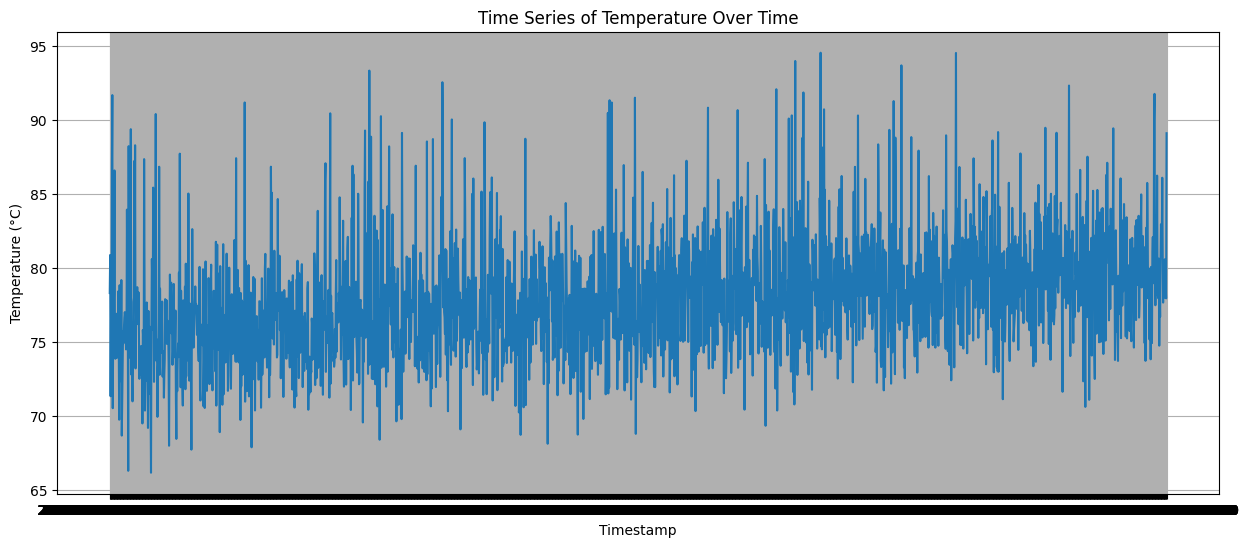

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='temperature', data=df)
plt.title('Time Series of Temperature Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

<Axes: >

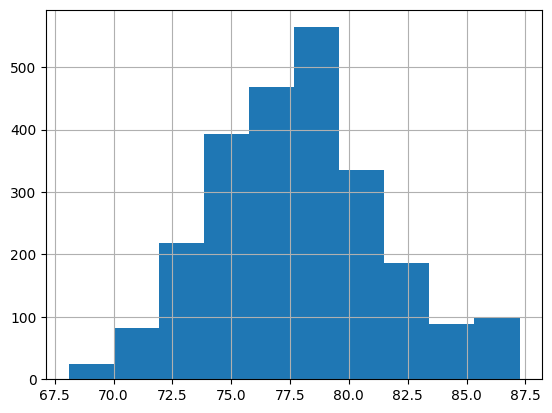

In [ ]:
df['temperature'].hist()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           2460 non-null   object 
 1   machine_id          2460 non-null   object 
 2   machine_type        2460 non-null   object 
 3   temperature         2411 non-null   float64
 4   vibration_level     2404 non-null   float64
 5   power_consumption   2405 non-null   float64
 6   pressure            2460 non-null   float64
 7   material_flow_rate  2460 non-null   float64
 8   cycle_time          2460 non-null   float64
 9   error_rate          2460 non-null   float64
 10  downtime            2460 non-null   int64  
 11  maintenance_flag    2460 non-null   int64  
 12  efficiency_score    2460 non-null   float64
 13  production_status   2460 non-null   int64  
dtypes: float64(8), int64(3), object(3)
memory usage: 269.2+ KB


- timestamp: Real-time data capture in minute-level intervals.
- machine_id: Unique identifier for each machine.
- machine_type: Type of production equipment.
- temperature: Machine temperature (°C).
- vibration_level: Vibration intensity indicating potential wear or misalignment.
- power_consumption: Energy usage in kilowatts (kW).
- pressure: System pressure in pascals (Pa).
- material_flow_rate: Speed of material movement through the system.
- cycle_time: Duration of one production cycle (seconds).
- error_rate: Proportion of defective products in the cycle.
- downtime: Machine inactivity time (minutes).
- maintenance_flag: Indicates whether maintenance is required (0 = No, 1 = Yes).
- efficiency_score: Overall production efficiency (0 to 100).
- production_status: Binary indicator for production efficiency (0 = Inefficient, 1 = Efficient).

Data Classification:

1. Identity
  - timetstamp
  - nmachine_id
  - machine_type

2. Sensors
  - temperature
  - vibration_level
  - power_consumption
  - pressure
  - material_flow_rate

3. production process
  - cycle_time
  - error_time
  - downtime

4. target
  - maintenance_flag
  - efficiency_score
  - production_status

In [ ]:
df.describe()

,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
count,2411.000000,2404.000000,2405.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.0
mean,77.938602,2.230957,18.422577,4.993933,20.032925,120.071115,0.794854,12.313008,0.059350,15.577832,0.0
std,3.944714,1.117706,2.669908,0.391494,1.511022,5.057995,0.085257,18.408838,0.236326,10.763130,0.0
min,66.136665,1.048872,10.326689,3.431040,15.376157,101.823999,0.540933,0.000000,0.000000,0.000000,0.0
25%,75.240313,1.806224,16.741559,4.732438,19.017601,116.624522,0.735993,0.000000,0.000000,5.760614,0.0
50%,77.734034,2.005956,18.159299,4.992426,20.031692,120.089570,0.789355,0.000000,0.000000,17.017636,0.0
75%,80.165885,2.230489,19.699169,5.251234,21.050319,123.567379,0.842145,36.000000,0.000000,23.980193,0.0
max,94.569177,9.109769,34.368410,6.351107,25.143366,142.395421,1.000000,50.000000,1.000000,45.906702,0.0


In [ ]:
# Looking at the target values

print(df['maintenance_flag'].value_counts())
print("\n")
print(df['production_status'].value_counts())
print("\n")
print(df['efficiency_score'].value_counts())

maintenance_flag
0    2314
1     146
Name: count, dtype: int64


production_status
0    2460
Name: count, dtype: int64


efficiency_score
0.000000     432
18.953423      1
26.770656      1
24.126845      1
25.472871      1
            ... 
18.736058      1
1.324043       1
33.826525      1
19.537946      1
21.187155      1
Name: count, Length: 2029, dtype: int64


After acquiring the dataset from Kaggle, an initial analysis revealed significant inconsistencies in the target variable, including overlapping labels, single-value entries, and high variance. Consequently, we opted to remove the original target and engineer new features based on domain knowledge to better align with our objectives.

In [ ]:
# delete target coloumns
df.drop(columns=['maintenance_flag','efficiency_score', 'production_status'], inplace=True)

In [ ]:
# convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

Check missing values and handle them

In [ ]:
df.isnull().sum()

,0
timestamp,0
machine_id,0
machine_type,0
temperature,49
vibration_level,56
power_consumption,55
pressure,0
material_flow_rate,0
cycle_time,0
error_rate,0


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.duplicated().sum()

np.int64(0)

Checking for outliers using IQR method:
Column 'temperature': 68 outliers found.
Column 'vibration_level': 132 outliers found.
Column 'power_consumption': 100 outliers found.
Column 'pressure': 25 outliers found.
Column 'material_flow_rate': 18 outliers found.
Column 'cycle_time': 17 outliers found.
Column 'error_rate': 7 outliers found.
Column 'downtime': No outliers found.


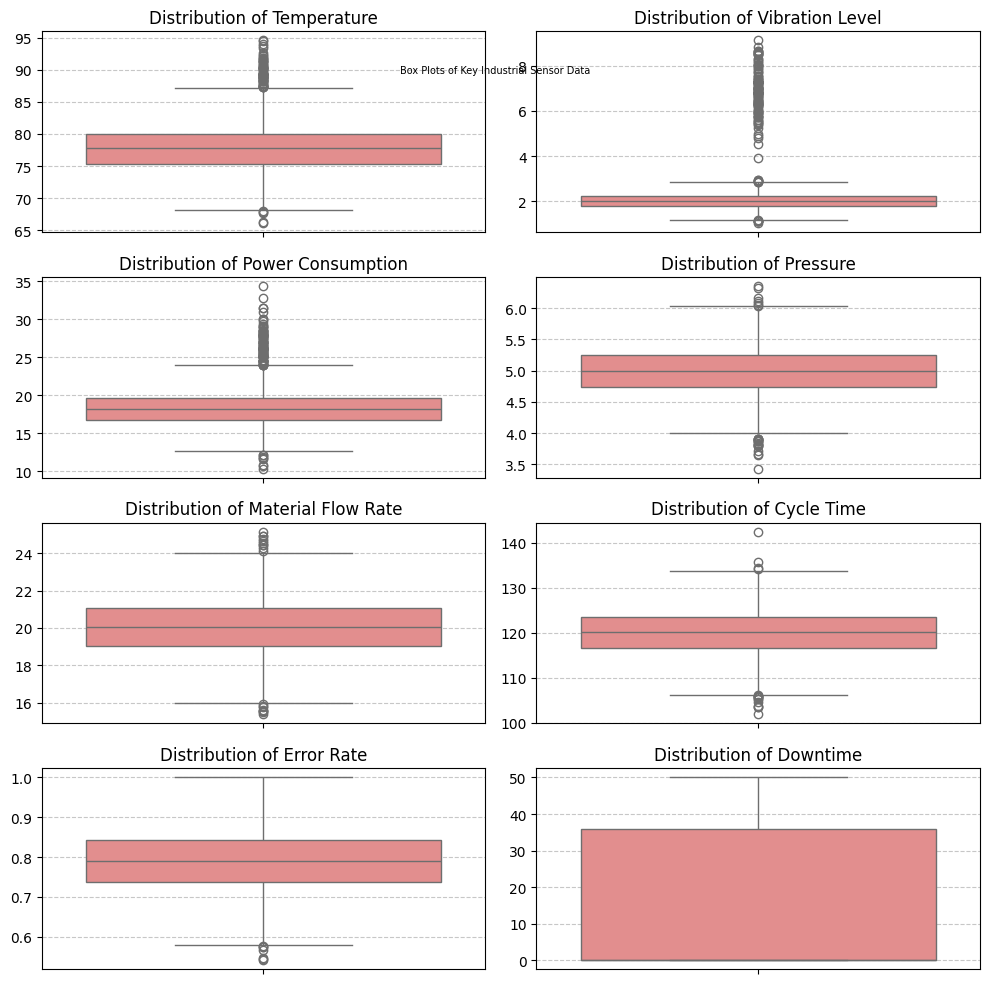

In [ ]:
print('Checking for outliers using IQR method:')
for column in df.select_dtypes(include=['number']).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{column}': {len(outliers)} outliers found.")
    else:
        print(f"Column '{column}': No outliers found.")


# Visualization of Outliers


# Columns for which to create box plots
columns_for_boxplot = [
    'temperature',
    'vibration_level',
    'power_consumption',
    'pressure',
    'material_flow_rate',
    'cycle_time',
    'error_rate',
    'downtime'
]

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12))
fig.suptitle('Box Plots of Key Industrial Sensor Data', fontsize=7, y=0.8)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_ylabel('') # Remove y-label to avoid clutter
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.88]) # Adjust layout to prevent suptitle overlap
plt.show()

As illustrated in the box plot above, there are numerous outliers. We have decided to retain these data points, as they may be critical indicators—such as signs that the machine requires maintenance or that the temperature has reached an overheating state.

therefore, we utilize Winsorization (also known as percentile capping), a statistical technique used to manage the impact of outliers in a dataset. Instead of completely removing them, this method replaces the extreme values with the nearest values within a predetermined range.

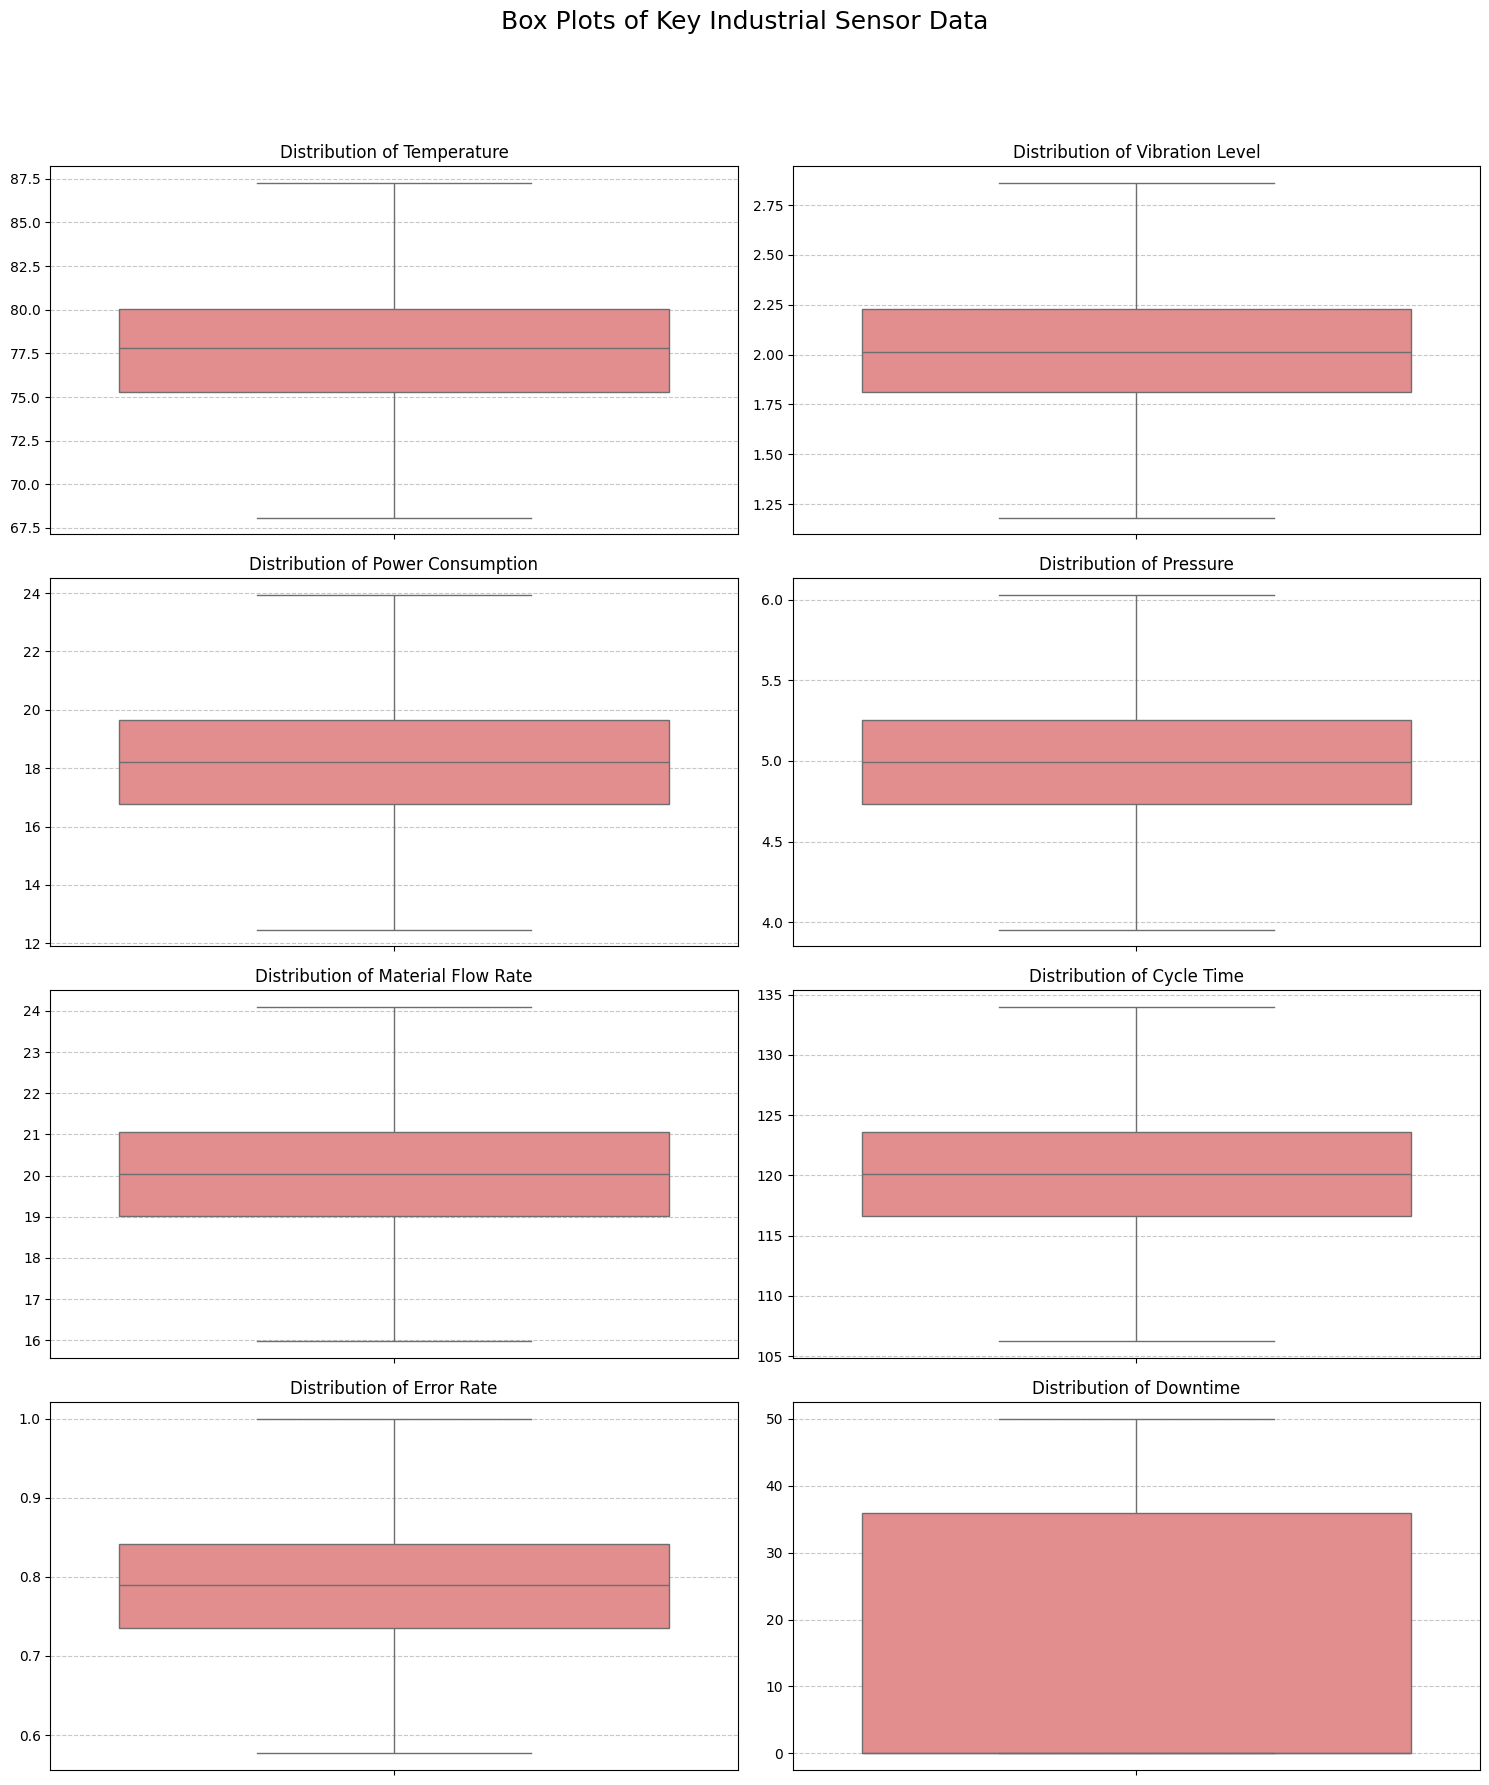

In [ ]:
#Capping (Winsorization) method

numeric_cols = [
"temperature",
"vibration_level",
"power_consumption",
"pressure",
"material_flow_rate",
"cycle_time",
"error_rate",
"downtime"
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


# visualization
# Columns for which to create box plots
columns_for_boxplot = [
    'temperature',
    'vibration_level',
    'power_consumption',
    'pressure',
    'material_flow_rate',
    'cycle_time',
    'error_rate',
    'downtime'
]

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Box Plots of Key Industrial Sensor Data', fontsize=18, y=0.92)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_ylabel('') # Remove y-label to avoid clutter
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.88]) # Adjust layout to prevent suptitle overlap
plt.show()

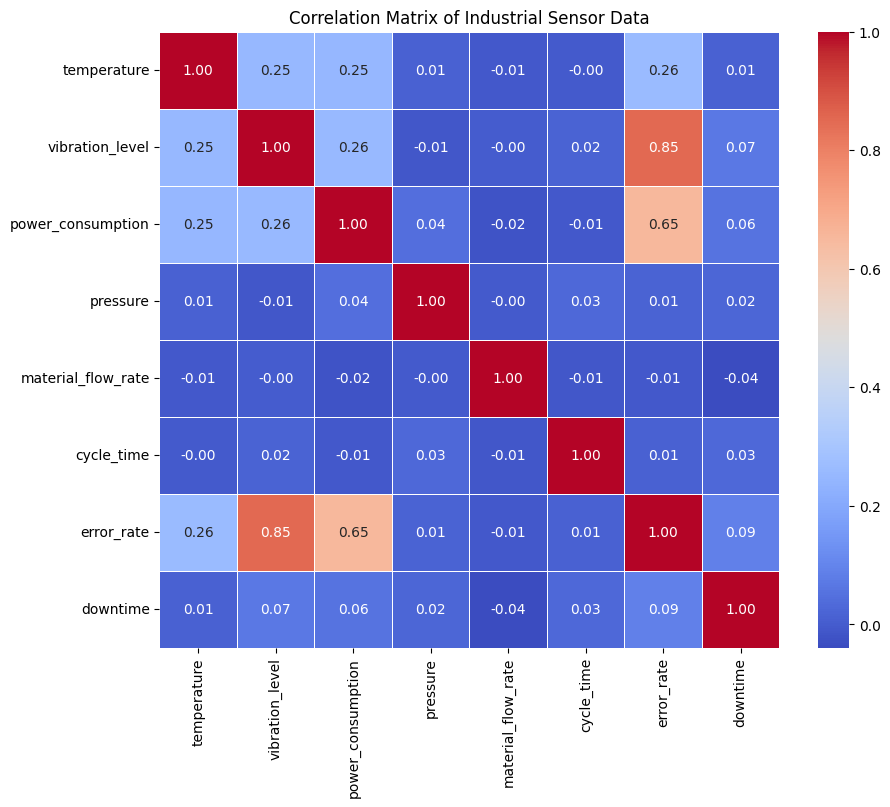

In [ ]:

# Select only numerical columns for correlation matrix
numerical_cols = [
    'temperature',
    'vibration_level',
    'power_consumption',
    'pressure',
    'material_flow_rate',
    'cycle_time',
    'error_rate',
    'downtime'
]

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Industrial Sensor Data')
plt.show()

as shown in matrix relationship, we can divide relationship among other variables:

1. the most significant relationship
  - error rate vs vibration level
  - error rate vs power consumption

2. moderate relationship
  - vib level vs power consumption
  - temperature vs vib level, power consumption, error rate

3. No significant relationship
- pressure, material flow rate, cycle time, downtime

In [ ]:
"""df["maintenance_flag"] = (
    (df["vibration_level"] > df["vibration_level"].quantile(0.9)) |
    (df["temperature"] > df["temperature"].quantile(0.9)) |
    (df["error_rate"] > df["error_rate"].quantile(0.9))
).astype(int)


df["efficiency_score"] = (
    df["material_flow_rate"] /
    (df["power_consumption"] * df["cycle_time"])
)


df["efficiency_score"] = (
    (df["efficiency_score"] - df["efficiency_score"].min()) /
    (df["efficiency_score"].max() - df["efficiency_score"].min())
)


df["production_status"] = 0

df.loc[df["error_rate"] > 0.2, "production_status"] = 1
df.loc[df["downtime"] > 10, "production_status"] = 2"""

'df["maintenance_flag"] = (\n    (df["vibration_level"] > df["vibration_level"].quantile(0.9)) |\n    (df["temperature"] > df["temperature"].quantile(0.9)) |\n    (df["error_rate"] > df["error_rate"].quantile(0.9))\n).astype(int)\n\n\ndf["efficiency_score"] = (\n    df["material_flow_rate"] /\n    (df["power_consumption"] * df["cycle_time"])\n)\n\n\ndf["efficiency_score"] = (\n    (df["efficiency_score"] - df["efficiency_score"].min()) /\n    (df["efficiency_score"].max() - df["efficiency_score"].min())\n)\n\n\ndf["production_status"] = 0\n\ndf.loc[df["error_rate"] > 0.2, "production_status"] = 1\ndf.loc[df["downtime"] > 10, "production_status"] = 2'

#Feature Selection and Scaling

In [ ]:
#Select relevant numerical features and scale them for unsupervised learning algorithms.

numerical_features = [
    'temperature',
    'vibration_level',
    'power_consumption',
    'pressure',
    'material_flow_rate',
    'cycle_time',
    'error_rate',
    'downtime'
]
df_scaled = df[numerical_features].copy()
print(df_scaled.head())

   temperature  vibration_level  power_consumption  pressure  \
0    78.302879         2.043751          23.059855  5.088076   
1    80.877076         2.175590          16.012814  5.412956   
2    71.315418         2.154465          15.759164  5.769405   
3    76.496198         2.245978          16.490268  4.618784   
4    73.612202         2.097302          18.064286  5.431250   

   material_flow_rate  cycle_time  error_rate  downtime  
0           20.011026  118.146510    0.883246         0  
1           18.375739  123.062058    0.777073        38  
2           17.112107  122.754064    0.757374        37  
3           21.090684  118.990270    0.796481        39  
4           20.868592  113.749872    0.813361         0  


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)
print(df_scaled.head())

   temperature  vibration_level  power_consumption  pressure  \
0     0.116146         0.015858           2.065354  0.241386   
1     0.812007         0.399074          -1.004863  1.080833   
2    -1.772714         0.337671          -1.115372  2.001851   
3    -0.372238         0.603670          -0.796848 -0.971202   
4    -1.151844         0.171515          -0.111088  1.128103   

   material_flow_rate  cycle_time  error_rate  downtime  
0           -0.013867   -0.384003    1.037975 -0.669000  
1           -1.102968    0.595216   -0.209444  1.395646  
2           -1.944547    0.533861   -0.440884  1.341313  
3            0.705185   -0.215919    0.018578  1.449978  
4            0.557272   -1.259851    0.216902 -0.669000  


#Anomaly Detection

In [ ]:
sensor_features = [
    'temperature',
    'vibration_level',
    'power_consumption',
    'error_rate',
    'downtime'
]
df_sensor_scaled = df_scaled[sensor_features]
print(df_sensor_scaled.head())

   temperature  vibration_level  power_consumption  error_rate  downtime
0     0.116146         0.015858           2.065354    1.037975 -0.669000
1     0.812007         0.399074          -1.004863   -0.209444  1.395646
2    -1.772714         0.337671          -1.115372   -0.440884  1.341313
3    -0.372238         0.603670          -0.796848    0.018578  1.449978
4    -1.151844         0.171515          -0.111088    0.216902 -0.669000


In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest model
# contamination is the proportion of outliers in the data set
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model to the scaled sensor data
iso_forest.fit(df_sensor_scaled)

# Predict anomalies (-1 for anomalies, 1 for normal)
anomaly_predictions = iso_forest.predict(df_sensor_scaled)

# Create the maintenance_flag in the original df
# Convert -1 (anomaly) to 1 (maintenance needed) and 1 (normal) to 0 (no maintenance needed)
df['maintenance_flag'] = np.where(anomaly_predictions == -1, 1, 0)

print(df[['temperature', 'vibration_level', 'power_consumption', 'error_rate', 'downtime', 'maintenance_flag']].head())

   temperature  vibration_level  power_consumption  error_rate  downtime  \
0    78.302879         2.043751          23.059855    0.883246         0   
1    80.877076         2.175590          16.012814    0.777073        38   
2    71.315418         2.154465          15.759164    0.757374        37   
3    76.496198         2.245978          16.490268    0.796481        39   
4    73.612202         2.097302          18.064286    0.813361         0   

   maintenance_flag  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


In [ ]:
print(df[df['maintenance_flag'] == 1].head())

             timestamp machine_id machine_type  temperature  vibration_level  \
5  2025-03-10 08:05:00       M004        Drill    86.820317         2.860356   
43 2025-03-10 08:43:00       M004     Conveyor    68.091828         1.330860   
44 2025-03-10 08:44:00       M004     Conveyor    87.252861         2.230957   
59 2025-03-10 08:59:00       M001          CNC    87.252861         2.860356   
76 2025-03-10 09:16:00       M004        Drill    69.473690         1.825995   

    power_consumption  pressure  material_flow_rate  cycle_time  error_rate  \
5           20.040572  4.965513           20.700636  121.528506    1.000000   
43          23.934765  5.191976           18.123158  124.739104    0.786454   
44          23.257803  4.597122           19.573718  113.084911    1.000000   
59          23.934765  5.534228           19.996631  121.309286    1.000000   
76          13.935292  4.710733           20.107131  118.326133    0.693568   

    downtime  maintenance_flag  
5          

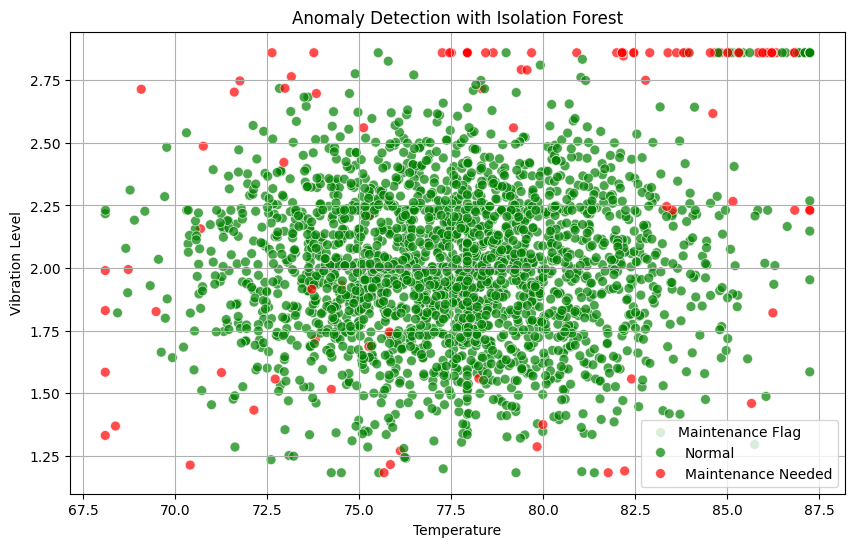

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='temperature',
    y='vibration_level',
    data=df,
    hue='maintenance_flag',  # 0 = normal, 1 = maintenance needed
    palette={0:'green', 1:'red'},  # 0 hijau, 1 merah
    s=50,
    alpha=0.7
)

plt.title('Anomaly Detection with Isolation Forest')
plt.xlabel('Temperature')
plt.ylabel('Vibration Level')

# update legend supaya label sesuai
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Normal', 'Maintenance Needed'], title='Maintenance Flag')

plt.grid(True)
plt.show()

# Derive production_status (K-Means Clustering)

Apply K-Means clustering on production-related features (e.g., `cycle_time`, `error_rate`, `downtime`, `material_flow_rate`) to categorize production status (e.g., 'Efficient', 'Moderately Efficient', 'Inefficient').

In [ ]:
production_features = [
    'cycle_time',
    'error_rate',
    'downtime',
    'material_flow_rate'
]
df_production_scaled = df_scaled[production_features]
print(df_production_scaled.head())

   cycle_time  error_rate  downtime  material_flow_rate
0   -0.384003    1.037975 -0.669000           -0.013867
1    0.595216   -0.209444  1.395646           -1.102968
2    0.533861   -0.440884  1.341313           -1.944547
3   -0.215919    0.018578  1.449978            0.705185
4   -1.259851    0.216902 -0.669000            0.557272


In [ ]:
from sklearn.cluster import KMeans

# Initialize KMeans model with 3 clusters for 'Efficient', 'Moderately Efficient', 'Inefficient'
# Using n_init='auto' to silence warning
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# Fit the model to the scaled production data
kmeans.fit(df_production_scaled)

# Get cluster labels
cluster_labels = kmeans.labels_

# Assign cluster labels to the original df as 'production_status'
df['production_status'] = cluster_labels

print(df[['cycle_time', 'error_rate', 'downtime', 'material_flow_rate', 'production_status']].head())
print("\nDistribution of production_status:\n", df['production_status'].value_counts())

   cycle_time  error_rate  downtime  material_flow_rate  production_status
0  118.146510    0.883246         0           20.011026                  4
1  123.062058    0.777073        38           18.375739                  6
2  122.754064    0.757374        37           17.112107                  6
3  118.990270    0.796481        39           21.090684                  7
4  113.749872    0.813361         0           20.868592                  1

Distribution of production_status:
 production_status
3    404
1    401
2    321
5    309
0    272
7    267
4    263
6    223
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


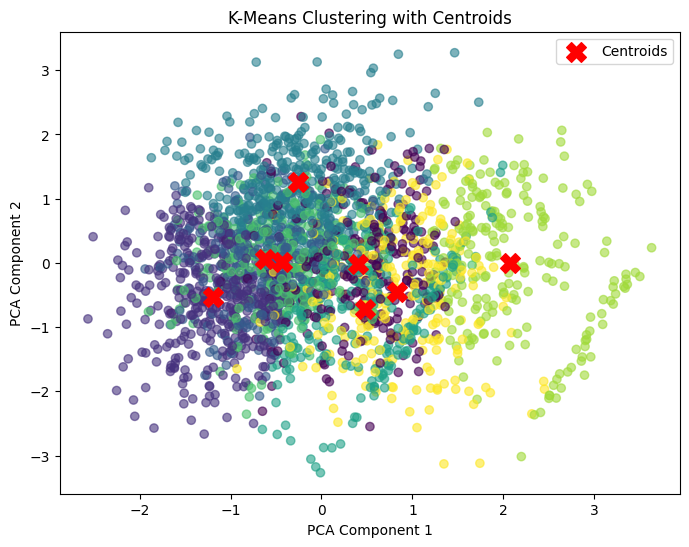

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# 1. Fit PCA ke data
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_production_scaled)  # hasilnya numpy array

# 2. Buat dataframe dari hasil PCA
df_pca = df.copy()  # salin df asli supaya ada cluster labels
df_pca['PCA1'] = pca_components[:,0]
df_pca['PCA2'] = pca_components[:,1]

# 3. Ambil centroids dari KMeans
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# 4. Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df_pca['PCA1'],
    df_pca['PCA2'],
    c=df_pca['production_status'],
    cmap='viridis',
    alpha=0.6
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

# Derive efficiency_score


In [ ]:
efficiency_features = [
    'material_flow_rate',
    'power_consumption',
    'cycle_time',
    'error_rate'
]

# Create a temporary DataFrame with scaled efficiency features
df_efficiency_scaled = df_scaled[efficiency_features].copy()

# Calculate a raw efficiency score
# Higher material_flow_rate is good, lower power_consumption, cycle_time, and error_rate are good.
# Using (1 - error_rate) to make higher values better for efficiency.
# Adding a small constant to denominators to avoid division by zero if scaled values can be zero, though StandardScaler makes this less likely for most real distributions.
df['efficiency_score'] = (df_efficiency_scaled['material_flow_rate'] * (1 - df_efficiency_scaled['error_rate'])) / \
                         (df_efficiency_scaled['power_consumption'] + df_efficiency_scaled['cycle_time'] + 1e-6)

# Min-Max scale the efficiency_score to a range of 0 to 100 for better interpretability
min_score = df['efficiency_score'].min()
max_score = df['efficiency_score'].max()

df['efficiency_score'] = ((df['efficiency_score'] - min_score) / (max_score - min_score)) * 100

print(df[['material_flow_rate', 'power_consumption', 'cycle_time', 'error_rate', 'efficiency_score']].head())
print("\nDescriptive statistics for efficiency_score:\n", df['efficiency_score'].describe())

   material_flow_rate  power_consumption  cycle_time  error_rate  \
0           20.011026          23.059855  118.146510    0.883246   
1           18.375739          16.012814  123.062058    0.777073   
2           17.112107          15.759164  122.754064    0.757374   
3           21.090684          16.490268  118.990270    0.796481   
4           20.868592          18.064286  113.749872    0.813361   

   efficiency_score  
0         65.701198  
1         65.863332  
2         65.941102  
3         65.667156  
4         65.685333  

Descriptive statistics for efficiency_score:
 count    2460.000000
mean       65.727187
std         1.703971
min         0.000000
25%        65.664737
50%        65.701505
75%        65.734831
max       100.000000
Name: efficiency_score, dtype: float64


## Visualize maintenance_flag



/tmp/ipykernel_195/709471531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='maintenance_flag', data=df, palette='viridis')


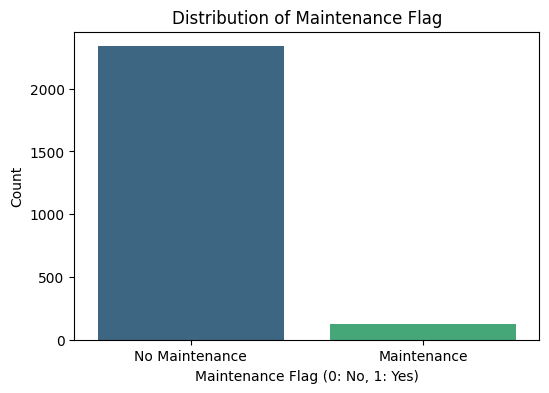

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='maintenance_flag', data=df, palette='viridis')
plt.title('Distribution of Maintenance Flag')
plt.xlabel('Maintenance Flag (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Maintenance', 'Maintenance'])
plt.show()

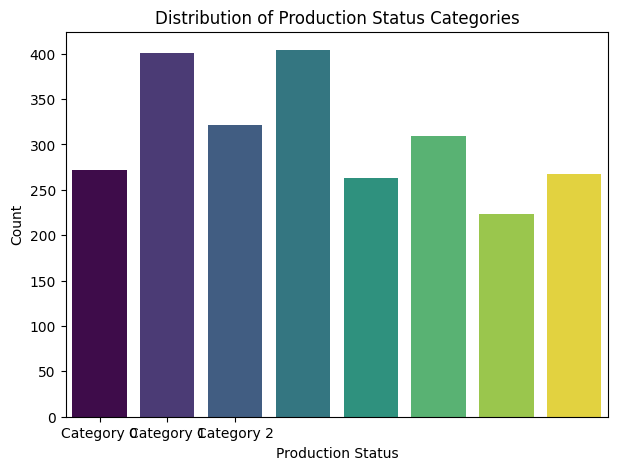

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='production_status', data=df, palette='viridis', hue='production_status', legend=False)
plt.title('Distribution of Production Status Categories')
plt.xlabel('Production Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Category 0', 'Category 1', 'Category 2'])
plt.show()

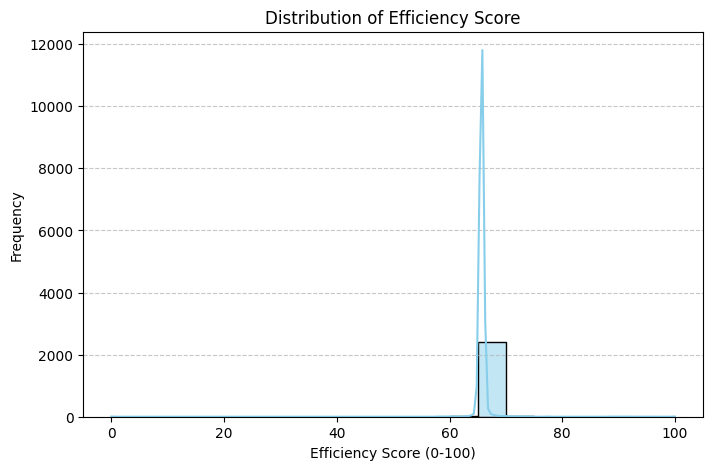

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['efficiency_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Efficiency Score')
plt.xlabel('Efficiency Score (0-100)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(df[['maintenance_flag', 'production_status', 'efficiency_score']].head())
print("\nFirst 5 rows of the updated DataFrame with new features:")
print(df.head())

   maintenance_flag  production_status  efficiency_score
0                 0                  4         65.701198
1                 0                  6         65.863332
2                 0                  6         65.941102
3                 0                  7         65.667156
4                 0                  1         65.685333

First 5 rows of the updated DataFrame with new features:
            timestamp machine_id machine_type  temperature  vibration_level  \
0 2025-03-10 08:00:00       M003       Welder    78.302879         2.043751   
1 2025-03-10 08:01:00       M004     Conveyor    80.877076         2.175590   
2 2025-03-10 08:02:00       M001        Drill    71.315418         2.154465   
3 2025-03-10 08:03:00       M003     Conveyor    76.496198         2.245978   
4 2025-03-10 08:04:00       M003          CNC    73.612202         2.097302   

   power_consumption  pressure  material_flow_rate  cycle_time  error_rate  \
0          23.059855  5.088076           20.011

In [ ]:
df.describe()

,timestamp,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,production_status,efficiency_score
count,2460,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,2025-03-11 04:29:30,77.873219,2.038295,18.319267,4.994655,20.031847,120.074153,0.794900,12.313008,0.050000,3.276016,65.727187
min,2025-03-10 08:00:00,68.091828,1.181959,12.472340,3.954245,15.968525,106.210237,0.576765,0.000000,0.000000,0.000000,0.000000
25%,2025-03-10 18:14:45,75.277215,1.811358,16.770749,4.732438,19.017601,116.624522,0.735993,0.000000,0.000000,1.000000,65.664737
50%,2025-03-11 04:29:30,77.814997,2.013409,18.214929,4.992426,20.031692,120.089570,0.789355,0.000000,0.000000,3.000000,65.701505
75%,2025-03-11 14:44:15,80.067474,2.230957,19.636355,5.251234,21.050319,123.567379,0.842145,36.000000,0.000000,5.000000,65.734831
max,2025-03-12 00:59:00,87.252861,2.860356,23.934765,6.029427,24.099396,133.981664,1.000000,50.000000,1.000000,7.000000,100.000000
std,NaN,3.700053,0.344103,2.295758,0.387095,1.501807,5.020887,0.085131,18.408838,0.217989,2.205725,1.703971
